# Pooled FoV Prediction Across the Full 360dataset

Generalizes the single-video/single-user FoV notebook to the **whole dataset**, using the folder structure from your `readme.txt`:

```
360dataset/
  content/
    saliency/videoname_saliency.mp4
    motion/videoname_motion.mp4
  sensory/
    raw/videoname_userXX_raw.csv          (unused -- orientation.csv is the cleaned, frame-aligned version)
    orientation/videoname_userXX_orientation.csv
    tile/videoname_userXX_tile.csv
```

**Same D-GAN architecture as before** (self-attention ConvLSTM encoders → VAE latent → GAN generator/discriminator, predicting a future tile-occupancy heatmap). Recent-history windows are 15/30/60 frames (short/medium/long, ~0.5s/1.0s/2.0s at 30fps). What's new here is entirely in the *data pipeline*:

1. **Auto-discovers every (video, user) trajectory** actually present on disk, rather than one fixed pair.
2. **Handles mixed video resolutions.** Each video's native tile grid is computed from its own resolution, then resized to one shared grid so a single model can train across videos of different sizes. If your dataset is actually all one resolution, this is a harmless no-op.
3. **Splits by whole trajectory**, not by time within one trajectory: some (video, user) pairs go entirely to train, others entirely to val/test — so the model is evaluated on video/viewer combinations it's never seen, which is the right test for a pooled/general predictor.
4. **Caches saliency/motion per VIDEO** (not per user) — multiple users watching the same video reuse one extraction.


## Honesty note — please read before running

Everything in this notebook's **model** and **single-trajectory windowing logic** was tested against your real `sport`/`user50` files in an earlier notebook and confirmed working (real training, real loss decreases, real evaluation).

The **new orchestration code** in this notebook — trajectory discovery, the mixed-resolution resize path, and the trajectory-level train/val/test split — has **not** been run against your actual multi-file dataset (I only have the single `sport`/`user50` example files; the full dataset wasn't uploaded). I did verify, without touching any of your data:
- the model builds and runs a training step on random dummy tensors of the right shapes (no errors),
- the resize-to-common-grid function works correctly on synthetic arrays,
- all files pass a Python syntax/import check.

So: the pieces are sound in isolation, but this specific combination hasn't seen your real folder yet. **Read the console output on your first run carefully** — in particular the discovered trajectory count and any `[skip]` warnings — before trusting downstream results. If something breaks or the discovered file counts look wrong, share the error/output and I'll fix it fast.


## 0. Setup

**Place this notebook directly inside the folder that contains `content/`, `sensory/`, and `readme`** (per your screenshot, that's the innermost `360dataset` folder — `.../dataset/360dataset/360dataset/`) and run it from there. `DATA_ROOT="."` below then just means "this same folder."

If you'd rather keep the notebook elsewhere, change `DATA_ROOT` to the full path of that folder instead.


In [1]:
# !pip install tensorflow-cpu opencv-python pandas numpy matplotlib --quiet

import warnings
warnings.filterwarnings("ignore")

import os, time
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("GPUs visible:", tf.config.list_physical_devices('GPU') or "none (running on CPU)")

DATA_ROOT = "."   # notebook is expected to live alongside content/ and sensory/ -- see markdown above


TensorFlow: 2.21.0
GPUs visible: none (running on CPU)


## 1. Config

Two settings worth checking before your first run:
- **`max_videos` / `max_users_per_video`** — caps on how much of the dataset to actually use. Left conservative by default for CPU feasibility; raise them once you've seen how long one video/user's extraction takes on your machine (printed during Section 3).
- **`grid_h` / `grid_w`** — the common tile grid every video gets resized to. Defaults to the 10×20 grid confirmed for the `sport` video; if your other videos are a very different aspect ratio, consider adjusting.


In [2]:
from dataclasses import dataclass, field
from typing import List


@dataclass
class FoVConfig:
    # ---- Dataset discovery ----
    data_root: str = "."             # expects data_root/content/{saliency,motion}/*.mp4
                                      #         data_root/sensory/{raw,orientation,tile}/*.csv
                                      # "." assumes the notebook itself lives in the same
                                      # folder as content/, sensory/, and readme (run it from there)
    cache_dir: str = "cache"        # where extracted/pooled video arrays get cached (per VIDEO, reused across users)

    # ---- Feasibility caps (CPU-friendly defaults -- raise these once you know your
    #      runtime budget and dataset size; see the printed estimate in Section 3) ----
    max_videos: int = 6             # use at most this many distinct videos
    max_users_per_video: int = 5    # use at most this many users per video
    random_seed: int = 0

    # ---- Common tile grid every video gets resized to (so the model can share
    #      one architecture across videos of different native resolution) ----
    grid_h: int = 10
    grid_w: int = 20
    tile_size: int = 192            # used only to compute each video's NATIVE grid before resizing

    # ---- Multi-resolution recent-history windows (frames @ assumed 30fps -- see
    #      the note in data_pipeline.py if your videos use a different frame rate) ----
    len_short: int = 15             # ~0.5s: immediate head motion
    len_medium: int = 30            # ~1.0s
    len_long: int = 60              # ~2.0s: coarser recent trend
    predict_horizon: int = 15
    window_stride: int = 2

    # ---- Encoder/decoder architecture ----
    convlstm_filters: List[int] = field(default_factory=lambda: [8, 4])
    kernel_size: int = 3
    latent_dim: int = 48

    # ---- Training ----
    batch_size: int = 8
    epochs: int = 5
    learning_rate: float = 0.001
    dropout: float = 0.3

    # ---- Loss weights ----
    lambda_rec_occ: float = 1.0
    lambda_rec_content: float = 0.5
    lambda_kl: float = 0.05
    lambda_gan: float = 0.05
    kl_anneal_steps: int = 200      # raised vs. the single-trajectory notebook since a
                                     # pooled dataset has many more total steps per epoch

    # ---- Split by WHOLE TRAJECTORY (one video+user pair), not by time within one
    #      trajectory -- see the notebook's markdown for why. ----
    train_frac: float = 0.70
    val_frac: float = 0.15
    # remaining ~0.15 -> test


## 2. Data pipeline

See the module docstring in the code cell below for the full explanation of what's new vs. the single-trajectory version. Key functions:
- `discover_trajectories` — globs `sensory/tile/*_tile.csv`, parses `{video}_{user}_tile.csv`, and keeps only trajectories with a complete matching set of files.
- `_process_trajectory` — parses one trajectory's tile CSV + extracts/caches its video's saliency/motion at native resolution, resizes everything to the common grid, then builds sliding windows (same logic as the single-video notebook).
- `build_pooled_dataset` — discovers trajectories, splits them 70/15/15 by whole trajectory, processes each, and pools windows within each split into train/val/test `tf.data.Dataset`s.


In [3]:
"""
Data pipeline for the FULL 360dataset structure (per readme.txt):

    data_root/
      content/
        saliency/videoname_saliency.mp4
        motion/videoname_motion.mp4
      sensory/
        raw/videoname_userXX_raw.csv           (unused -- see single-video notebook's note)
        orientation/videoname_userXX_orientation.csv
        tile/videoname_userXX_tile.csv

WHAT'S NEW vs. the single-video/user notebook (which was tested against real
`sport`/`user50` files)
  - `discover_trajectories`: globs every (video, user) pair actually present on
    disk, rather than assuming one fixed video/user.
  - Mixed-resolution handling: each video's NATIVE tile grid is computed from
    its own saliency mp4 (native_h = video_height/tile_size, native_w =
    video_width/tile_size). Tile occupancy, saliency, and motion are all built
    at that native resolution, then resized (`resize_grid_sequence`, via
    per-frame cv2.resize) down/up to one shared `target_grid_h x target_grid_w`
    -- so a single model can train across videos shot at different
    resolutions. If your dataset is actually all one resolution, this is a
    no-op (resize to the same size), so it's safe either way.
  - Trajectory-level train/val/test split: entire (video, user) trajectories
    are assigned wholly to train, val, or test -- never split within a
    trajectory -- so the model is tested on genuinely unseen video/viewer
    combinations, appropriate for a pooled/general model (as opposed to the
    single-trajectory notebook, which necessarily split chronologically
    within its one 60s clip).
  - Per-VIDEO caching (not per video+user): saliency/motion content is the
    same regardless of which user is watching, so it's extracted and cached
    once per video and reused across all of that video's users.

HONESTY NOTE: this file has NOT been executed against your actual multi-file
dataset (only against the single sport/user50 files from the earlier
notebook, whose logic this reuses/generalizes). Defensive error handling is
included (a malformed or missing file for one trajectory is skipped with a
warning rather than crashing the whole run), but please read the console
output on your first run and sanity-check the discovered trajectory count
before trusting the results.
"""

import glob
import os
import re
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf


# =============================================================================
# Discovery
# =============================================================================
TRAJ_RE = re.compile(r"^(?P<video>.+)_(?P<user>user\d+)_tile\.csv$")


def discover_trajectories(data_root, max_videos=None, max_users_per_video=None, seed=0):
    """Finds every (video, user) pair that has a complete set of files:
    tile.csv, orientation.csv, and that video's saliency/motion mp4s.
    Returns a list of dicts, one per usable trajectory."""
    tile_dir = os.path.join(data_root, "sensory", "tile")
    orient_dir = os.path.join(data_root, "sensory", "orientation")
    sal_dir = os.path.join(data_root, "content", "saliency")
    mot_dir = os.path.join(data_root, "content", "motion")

    tile_files = sorted(glob.glob(os.path.join(tile_dir, "*_tile.csv")))
    if not tile_files:
        raise FileNotFoundError(
            f"No *_tile.csv files found under {tile_dir}. Check `data_root` points at the "
            f"folder that directly contains content/ and sensory/ (per readme.txt)."
        )

    by_video = {}
    for path in tile_files:
        m = TRAJ_RE.match(os.path.basename(path))
        if not m:
            print(f"[skip] couldn't parse video/user from filename: {path}")
            continue
        video, user = m.group("video"), m.group("user")

        orient_path = os.path.join(orient_dir, f"{video}_{user}_orientation.csv")
        sal_path = os.path.join(sal_dir, f"{video}_saliency.mp4")
        mot_path = os.path.join(mot_dir, f"{video}_motion.mp4")
        missing = [p for p in [orient_path, sal_path, mot_path] if not os.path.exists(p)]
        if missing:
            print(f"[skip] {video}/{user}: missing {missing}")
            continue

        by_video.setdefault(video, []).append({
            "video": video, "user": user, "tile_path": path,
            "orient_path": orient_path, "sal_path": sal_path, "mot_path": mot_path,
        })

    rng = np.random.default_rng(seed)
    videos = sorted(by_video.keys())
    rng.shuffle(videos)
    if max_videos:
        videos = videos[:max_videos]

    trajectories = []
    for video in videos:
        users = by_video[video]
        rng.shuffle(users)
        if max_users_per_video:
            users = users[:max_users_per_video]
        trajectories.extend(users)

    print(f"Discovered {len(by_video)} videos total; using {len(videos)} videos, "
          f"{len(trajectories)} (video, user) trajectories after caps.")
    return trajectories


def split_trajectories(trajectories, train_frac, val_frac, seed=0):
    """Splits the TRAJECTORY LIST (not individual frames/windows) into
    train/val/test, so entire (video, user) pairs are held out together."""
    rng = np.random.default_rng(seed + 1)  # different seed than discovery's shuffle
    idx = np.arange(len(trajectories))
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_idx, val_idx, test_idx = idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]
    to_list = lambda ii: [trajectories[i] for i in ii]
    return to_list(train_idx), to_list(val_idx), to_list(test_idx)


# =============================================================================
# Per-trajectory parsing (native resolution)
# =============================================================================
def get_video_grid_shape(video_path, tile_size):
    cap = cv2.VideoCapture(video_path)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if w % tile_size or h % tile_size:
        print(f"[warn] {video_path}: {w}x{h} isn't an exact multiple of tile_size={tile_size}; "
              f"grid will be floor-rounded ({w//tile_size}x{h//tile_size}), edge tiles ignored.")
    return h // tile_size, w // tile_size, n, fps


def parse_tile_csv_native(path, native_grid_h, native_grid_w):
    """Ragged tile-list CSV -> dense (n_frames, native_grid_h, native_grid_w) binary array."""
    occ = []
    with open(path) as f:
        f.readline()  # header
        for line in f:
            parts = [p.strip() for p in line.strip().split(",")]
            if not parts or parts[0] == "":
                continue
            tiles = [int(t) for t in parts[1:] if t != ""]
            grid = np.zeros((native_grid_h, native_grid_w), dtype=np.float32)
            for t in tiles:
                r, c = divmod(t, native_grid_w)
                if 0 <= r < native_grid_h and 0 <= c < native_grid_w:
                    grid[r, c] = 1.0
            occ.append(grid)
    return np.stack(occ).astype(np.float32)


def extract_pooled_video_native(path, native_grid_h, native_grid_w, max_frames=None, verbose_every=300):
    cap = cv2.VideoCapture(path)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if max_frames:
        n = min(n, max_frames)
    out = np.zeros((n, native_grid_h, native_grid_w), dtype=np.float32)
    for i in range(n):
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        out[i] = cv2.resize(gray, (native_grid_w, native_grid_h), interpolation=cv2.INTER_AREA).astype(np.float32)
        if verbose_every and (i + 1) % verbose_every == 0:
            print(f"    ...{os.path.basename(path)}: {i+1}/{n} frames")
    cap.release()
    return out


def resize_grid_sequence(arr, target_h, target_w):
    """Resizes each frame of a (T, H, W) array to (T, target_h, target_w).
    No-op (returns a copy) if already the target shape."""
    T, H, W = arr.shape
    if H == target_h and W == target_w:
        return arr.copy()
    interp = cv2.INTER_AREA if (target_h <= H and target_w <= W) else cv2.INTER_LINEAR
    out = np.zeros((T, target_h, target_w), dtype=np.float32)
    for t in range(T):
        out[t] = cv2.resize(arr[t], (target_w, target_h), interpolation=interp)
    return out


def minmax_normalize(x):
    lo, hi = float(x.min()), float(x.max())
    hi = hi if hi > lo else lo + 1.0
    return (x - lo) / (hi - lo), (lo, hi)


# =============================================================================
# Per-trajectory window building (identical logic to the single-video notebook)
# =============================================================================
def build_trajectory_windows(occupancy, saliency_norm, motion_norm, config, meta_tag):
    c = config
    T = occupancy.shape[0]
    start = max(c.len_short, c.len_medium, c.len_long)
    end = T - c.predict_horizon
    if end <= start:
        print(f"[skip] {meta_tag}: only {T} frames, not enough for the configured window lengths.")
        return None

    tile_short, tile_medium, tile_long = [], [], []
    sal_hist, mot_hist, targets, content_targets, tags = [], [], [], [], []

    for t in range(start, end, c.window_stride):
        tile_short.append(occupancy[t - c.len_short:t])
        tile_medium.append(occupancy[t - c.len_medium:t])
        tile_long.append(occupancy[t - c.len_long:t])
        sal_hist.append(saliency_norm[t - c.len_medium:t])
        mot_hist.append(motion_norm[t - c.len_medium:t])
        targets.append(occupancy[t:t + c.predict_horizon])
        content_targets.append(np.stack([saliency_norm[t - c.len_medium:t],
                                          motion_norm[t - c.len_medium:t]], axis=-1))
        tags.append(meta_tag)

    if not targets:
        return None

    return {
        "tile_short": np.stack(tile_short)[..., None].astype(np.float32),
        "tile_medium": np.stack(tile_medium)[..., None].astype(np.float32),
        "tile_long": np.stack(tile_long)[..., None].astype(np.float32),
        "saliency_hist": np.stack(sal_hist)[..., None].astype(np.float32),
        "motion_hist": np.stack(mot_hist)[..., None].astype(np.float32),
        "target": np.stack(targets)[..., None].astype(np.float32),
        "content_target": np.stack(content_targets).astype(np.float32),
        "tag": np.array(tags),
    }


def _concat_windows(list_of_windows):
    list_of_windows = [w for w in list_of_windows if w is not None]
    if not list_of_windows:
        return None
    keys = list_of_windows[0].keys()
    return {k: np.concatenate([w[k] for w in list_of_windows], axis=0) for k in keys}


def make_tf_dataset(windows, config, shuffle=True, drop_remainder=True):
    inputs = {k: windows[k] for k in ["tile_short", "tile_medium", "tile_long", "saliency_hist", "motion_hist"]}
    target = windows["target"]
    content_target = windows["content_target"]
    n = target.shape[0]
    ds = tf.data.Dataset.from_tensor_slices((inputs, target, content_target))
    if shuffle:
        ds = ds.shuffle(min(n, 4000))
    return ds.batch(config.batch_size, drop_remainder=drop_remainder).prefetch(tf.data.AUTOTUNE)


# =============================================================================
# Top-level orchestration
# =============================================================================
def _process_trajectory(traj, config):
    """Parses + pools + resizes one (video, user) trajectory to the common
    target grid, using per-VIDEO caching for the (expensive) saliency/motion
    extraction so multiple users of the same video reuse one extraction."""
    video, user = traj["video"], traj["user"]
    tag = f"{video}/{user}"
    os.makedirs(config.cache_dir, exist_ok=True)

    try:
        native_h, native_w, n_video_frames, fps = get_video_grid_shape(traj["sal_path"], config.tile_size)
    except Exception as e:
        print(f"[skip] {tag}: couldn't read video metadata ({e})")
        return None

    sal_cache = os.path.join(config.cache_dir, f"{video}_saliency_native.npy")
    mot_cache = os.path.join(config.cache_dir, f"{video}_motion_native.npy")
    try:
        if os.path.exists(sal_cache):
            saliency_native = np.load(sal_cache)
        else:
            print(f"  Extracting saliency for video '{video}' (one-time, reused across its users)...")
            saliency_native = extract_pooled_video_native(traj["sal_path"], native_h, native_w)
            np.save(sal_cache, saliency_native)
        if os.path.exists(mot_cache):
            motion_native = np.load(mot_cache)
        else:
            print(f"  Extracting motion for video '{video}' (one-time, reused across its users)...")
            motion_native = extract_pooled_video_native(traj["mot_path"], native_h, native_w)
            np.save(mot_cache, motion_native)
    except Exception as e:
        print(f"[skip] {tag}: video extraction failed ({e})")
        return None

    try:
        occupancy_native = parse_tile_csv_native(traj["tile_path"], native_h, native_w)
    except Exception as e:
        print(f"[skip] {tag}: tile CSV parsing failed ({e})")
        return None

    n = min(len(occupancy_native), len(saliency_native), len(motion_native))
    if n < max(config.len_short, config.len_medium, config.len_long) + config.predict_horizon + 1:
        print(f"[skip] {tag}: only {n} aligned frames, too short for this config.")
        return None
    occupancy_native = occupancy_native[:n]
    saliency_native = saliency_native[:n]
    motion_native = motion_native[:n]

    occupancy = resize_grid_sequence(occupancy_native, config.grid_h, config.grid_w)
    # Binarize after resize (interpolation can produce values in between 0/1 at tile boundaries)
    occupancy = (occupancy >= 0.5).astype(np.float32)
    saliency = resize_grid_sequence(saliency_native, config.grid_h, config.grid_w)
    motion = resize_grid_sequence(motion_native, config.grid_h, config.grid_w)
    saliency_norm, _ = minmax_normalize(saliency)
    motion_norm, _ = minmax_normalize(motion)

    return build_trajectory_windows(occupancy, saliency_norm, motion_norm, config, tag)


def build_pooled_dataset(config):
    """Full pipeline: discover trajectories -> split by whole trajectory into
    train/val/test -> process + window each trajectory -> pool windows within
    each split -> wrap into tf.data.Datasets."""
    trajectories = discover_trajectories(config.data_root, config.max_videos,
                                          config.max_users_per_video, config.random_seed)
    train_traj, val_traj, test_traj = split_trajectories(trajectories, config.train_frac,
                                                           config.val_frac, config.random_seed)
    print(f"Trajectory split -> train: {len(train_traj)}  val: {len(val_traj)}  test: {len(test_traj)}")

    def build_split(traj_list, name):
        print(f"\nProcessing {name} split ({len(traj_list)} trajectories)...")
        windows_list = []
        for traj in traj_list:
            w = _process_trajectory(traj, config)
            if w is not None:
                windows_list.append(w)
        pooled = _concat_windows(windows_list)
        if pooled is None:
            print(f"[warn] {name} split ended up with 0 usable windows.")
        return pooled

    train_windows = build_split(train_traj, "TRAIN")
    val_windows = build_split(val_traj, "VAL")
    test_windows = build_split(test_traj, "TEST")

    train_ds = make_tf_dataset(train_windows, config, shuffle=True, drop_remainder=True) if train_windows else None
    val_ds = make_tf_dataset(val_windows, config, shuffle=False, drop_remainder=False) if val_windows else None
    test_ds = make_tf_dataset(test_windows, config, shuffle=False, drop_remainder=False) if test_windows else None

    meta = {
        "train_trajectories": [f"{t['video']}/{t['user']}" for t in train_traj],
        "val_trajectories": [f"{t['video']}/{t['user']}" for t in val_traj],
        "test_trajectories": [f"{t['video']}/{t['user']}" for t in test_traj],
        "n_train_windows": 0 if train_windows is None else train_windows["target"].shape[0],
        "n_val_windows": 0 if val_windows is None else val_windows["target"].shape[0],
        "n_test_windows": 0 if test_windows is None else test_windows["target"].shape[0],
    }
    return train_ds, val_ds, test_ds, meta


## 3. Build the dataset

This is the step to watch closely on your first run — it will print the discovered video/trajectory counts and any skipped files, then extract+cache each used video's saliency/motion (the slow part: roughly 2-4 minutes **per video**, not per trajectory, since it's cached and reused across that video's users).

**Before running on the full dataset**, consider first running with very small caps (e.g. `max_videos=1, max_users_per_video=2`) to confirm the discovery and parsing work correctly against your real folder structure, then raise the caps once you've confirmed it.


In [4]:
cfg = FoVConfig(
    data_root=DATA_ROOT,
    max_videos=6,             # raise once you know your per-video extraction time
    max_users_per_video=5,
    epochs=5,
)

t0 = time.time()
train_ds, val_ds, test_ds, meta = build_pooled_dataset(cfg)
print(f"\nTotal pipeline build time: {time.time()-t0:.1f}s")
print(f"Train windows: {meta['n_train_windows']}  |  Val windows: {meta['n_val_windows']}  |  Test windows: {meta['n_test_windows']}")
print(f"\nTrain trajectories: {meta['train_trajectories']}")
print(f"Val trajectories:   {meta['val_trajectories']}")
print(f"Test trajectories:  {meta['test_trajectories']}")

assert train_ds is not None and meta['n_train_windows'] > 0, \
    "No training windows were built -- check the [skip] warnings above and DATA_ROOT."


Discovered 10 videos total; using 6 videos, 30 (video, user) trajectories after caps.
Trajectory split -> train: 21  val: 4  test: 5

Processing TRAIN split (21 trajectories)...
  Extracting saliency for video 'drive' (one-time, reused across its users)...
    ...drive_saliency.mp4: 300/1800 frames
    ...drive_saliency.mp4: 600/1800 frames
    ...drive_saliency.mp4: 900/1800 frames
    ...drive_saliency.mp4: 1200/1800 frames
    ...drive_saliency.mp4: 1500/1800 frames
    ...drive_saliency.mp4: 1800/1800 frames
  Extracting motion for video 'drive' (one-time, reused across its users)...
    ...drive_motion.mp4: 300/1800 frames
    ...drive_motion.mp4: 600/1800 frames
    ...drive_motion.mp4: 900/1800 frames
    ...drive_motion.mp4: 1200/1800 frames
    ...drive_motion.mp4: 1500/1800 frames
    ...drive_motion.mp4: 1800/1800 frames
  Extracting saliency for video 'panel' (one-time, reused across its users)...
    ...panel_saliency.mp4: 300/1800 frames
    ...panel_saliency.mp4: 600/180

In [5]:
# Inspect one training batch
batch = next(iter(train_ds))
inputs, target, content_target = batch
for k, v in inputs.items():
    print(f"{k:15s} {tuple(v.shape)}")
print(f"{'target':15s} {tuple(target.shape)}")
print(f"{'content_target':15s} {tuple(content_target.shape)}")


tile_short      (8, 15, 10, 20, 1)
tile_medium     (8, 30, 10, 20, 1)
tile_long       (8, 60, 10, 20, 1)
saliency_hist   (8, 30, 10, 20, 1)
motion_hist     (8, 30, 10, 20, 1)
target          (8, 15, 10, 20, 1)
content_target  (8, 30, 10, 20, 2)


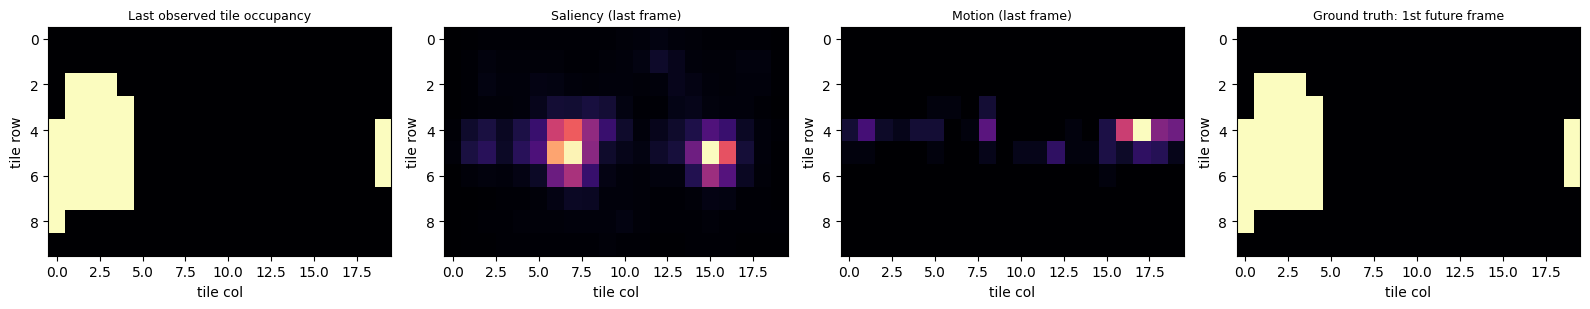

In [6]:
# Visualize one example window
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
titles = ["Last observed tile occupancy", "Saliency (last frame)", "Motion (last frame)", "Ground truth: 1st future frame"]
maps = [inputs["tile_short"][0, -1, :, :, 0].numpy(),
        inputs["saliency_hist"][0, -1, :, :, 0].numpy(),
        inputs["motion_hist"][0, -1, :, :, 0].numpy(),
        target[0, 0, :, :, 0].numpy()]
for ax, m, t in zip(axes, maps, titles):
    ax.imshow(m, cmap="magma", aspect="auto")
    ax.set_title(t, fontsize=9); ax.set_xlabel("tile col"); ax.set_ylabel("tile row")
plt.tight_layout()
plt.show()


## 4. Model

Unchanged from the single-trajectory notebook (already tested there) — the pooled dataset just feeds it more, more varied windows.


In [7]:
"""
FoV prediction model -- D-GAN (Saxena & Cao, 2022) architecture retargeted
from taxi-demand-grid prediction to tile-occupancy-grid (FoV) prediction.

WHAT'S REUSED UNCHANGED FROM dgan_model.py
  - SelfAttention2D (Eq. 7's "Attention(...)")
  - build_branch_encoder (ConvLSTM stack -> 3D-Conv -> self-attention -> MLP)
  - build_discriminator ((map, latent) pair -> ConvLSTM/3D-Conv -> sigmoid)
  - the overall VAE+GAN training step structure (Eq. 15-23)

WHAT'S ADAPTED FOR THIS DATASET
  - Two-level temporal correlation -> "multi-resolution recent history".
    The paper's hour/day/week resolutions (Section 4.2) exist because urban
    demand has daily and weekly cycles. A 60-second HMD viewing session has
    no such cycles, so the analogous idea here is three resolutions of
    *recent* history instead: a short window (immediate head motion), a
    medium window, and a long window (coarser trend) -- same architecture,
    rescaled from hours to frames.
  - External factors (PoI/weather/weekday, all static or city-wide) ->
    saliency + motion history. Unlike PoI/weather, these ARE genuinely
    spatially-varying per-tile signals (a saliency/motion map has real
    structure across the grid), so if anything they fuse in more naturally
    here than the original external factors did.
  - Reconstruction loss: the paper uses L2 (Eq. 15) because taxi demand is
    a continuous count. Tile occupancy is a binary mask (tile is/isn't in
    the viewer's FoV), so we use binary cross-entropy for the occupancy
    head instead -- the standard, better-justified loss for a 0/1 target
    (the KL and adversarial terms, Eq. 17/19/20, are unchanged).
"""

import numpy as np
import tensorflow as tf
from tensorflow import keras


class SelfAttention2D(keras.layers.Layer):
    """Identical to dgan_model.py's SelfAttention2D (Eq. 7's Attention term)."""
    def build(self, input_shape):
        c = input_shape[-1]
        self.c_bar = max(c // 8, 1)
        self.f_conv = keras.layers.Conv2D(self.c_bar, 1, name=self.name + "_f")
        self.g_conv = keras.layers.Conv2D(self.c_bar, 1, name=self.name + "_g")
        self.h_conv = keras.layers.Conv2D(c, 1, name=self.name + "_h")
        self.gamma = self.add_weight(name=self.name + "_gamma", shape=(), initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, x):
        shape = tf.shape(x)
        B, H, W = shape[0], shape[1], shape[2]
        C = x.shape[-1]
        f = tf.reshape(self.f_conv(x), [B, H * W, self.c_bar])
        g = tf.reshape(self.g_conv(x), [B, H * W, self.c_bar])
        h = tf.reshape(self.h_conv(x), [B, H * W, C])
        attn = tf.nn.softmax(tf.matmul(f, g, transpose_b=True), axis=-1)
        out = tf.reshape(tf.matmul(attn, h), [B, H, W, C])
        return x + self.gamma * out


def build_branch_encoder(input_shape, config, name):
    """Identical structure to dgan_model.py's build_branch_encoder (Eq. 7)."""
    inp = keras.Input(shape=input_shape, name=f"{name}_input")
    x = inp
    for i, f in enumerate(config.convlstm_filters):
        x = keras.layers.ConvLSTM2D(f, config.kernel_size, padding="same", return_sequences=True,
                                     name=f"{name}_convlstm{i}")(x)
        x = keras.layers.BatchNormalization(name=f"{name}_bn{i}")(x)
    x = keras.layers.Conv3D(config.convlstm_filters[-1], 3, padding="same", activation="relu",
                             name=f"{name}_conv3d")(x)
    x = keras.layers.MaxPooling3D(pool_size=(2, 2, 2), padding="same", name=f"{name}_pool3d")(x)
    x = keras.layers.BatchNormalization(name=f"{name}_bn3d")(x)
    x = keras.layers.Lambda(lambda t: tf.reduce_mean(t, axis=1), name=f"{name}_time_pool")(x)
    x = SelfAttention2D(name=f"{name}_selfattn")(x)
    x = keras.layers.Flatten(name=f"{name}_flatten")(x)
    x = keras.layers.Dropout(config.dropout, name=f"{name}_dropout")(x)
    x = keras.layers.Dense(config.latent_dim, activation="relu", name=f"{name}_mlp")(x)
    return keras.Model(inp, x, name=f"{name}_encoder")


def build_fov_correlation_network(config):
    """Spatio-temporal correlation network (Section 4.2), retargeted:
    3 recent-history resolutions of tile occupancy (short/medium/long) +
    2 content branches (saliency, motion history) -> (mu, logvar)."""
    c = config
    short_shape = (c.len_short, c.grid_h, c.grid_w, 1)
    medium_shape = (c.len_medium, c.grid_h, c.grid_w, 1)
    long_shape = (c.len_long, c.grid_h, c.grid_w, 1)
    sal_shape = (c.len_medium, c.grid_h, c.grid_w, 1)
    mot_shape = (c.len_medium, c.grid_h, c.grid_w, 1)

    short_in = keras.Input(shape=short_shape, name="tile_short")
    medium_in = keras.Input(shape=medium_shape, name="tile_medium")
    long_in = keras.Input(shape=long_shape, name="tile_long")
    sal_in = keras.Input(shape=sal_shape, name="saliency_hist")
    mot_in = keras.Input(shape=mot_shape, name="motion_hist")

    v_short = build_branch_encoder(short_shape, c, "short")(short_in)
    v_medium = build_branch_encoder(medium_shape, c, "medium")(medium_in)
    v_long = build_branch_encoder(long_shape, c, "long")(long_in)
    vc_x = keras.layers.Concatenate(name="concat_tile")([v_short, v_medium, v_long])
    vc_x = keras.layers.Dense(c.latent_dim, activation="relu", name="tile_fusion_mlp")(vc_x)

    v_sal = build_branch_encoder(sal_shape, c, "saliency")(sal_in)
    v_mot = build_branch_encoder(mot_shape, c, "motion")(mot_in)
    vc_content = keras.layers.Concatenate(name="concat_content")([v_sal, v_mot])
    vc_content = keras.layers.Dense(c.latent_dim, activation="relu", name="content_fusion_mlp")(vc_content)

    vs = keras.layers.Concatenate(name="concat_shared")([vc_x, vc_content])
    vs = keras.layers.Dense(c.latent_dim, activation="relu", name="shared_mlp")(vs)
    mu = keras.layers.Dense(c.latent_dim, name="mu")(vs)
    logvar = keras.layers.Dense(c.latent_dim, name="logvar")(vs)

    inputs = [short_in, medium_in, long_in, sal_in, mot_in]
    return keras.Model(inputs, [mu, logvar], name="FoV_Correlation_Network")


def build_fov_generator(config):
    """Generator/Decoder (Eq. 11-12), retargeted: main head predicts the
    future tile-occupancy grid (sigmoid -> per-tile FoV probability);
    auxiliary head reconstructs the historical saliency+motion content
    (encourages the latent to retain full content information, same
    spirit as the paper's external-factor reconstruction, Eq. 11)."""
    c = config
    latent_in = keras.Input(shape=(c.latent_dim,), name="G_latent_in")
    vt1 = keras.layers.Dense(c.latent_dim, activation="relu", name="G_vt1_mlp")(latent_in)
    base_f = c.convlstm_filters[-1]

    # ---- main head: future tile-occupancy probability, (predict_horizon, H, W, 1) ----
    st = keras.layers.Dense(c.predict_horizon * c.grid_h * c.grid_w * base_f, activation="relu",
                             name="G_occ_dense")(vt1)
    st = keras.layers.Reshape((c.predict_horizon, c.grid_h, c.grid_w, base_f), name="G_occ_reshape")(st)
    for i, f in enumerate(reversed(c.convlstm_filters)):
        st = keras.layers.ConvLSTM2D(f, c.kernel_size, padding="same", return_sequences=True,
                                      name=f"G_occ_convlstm{i}")(st)
        st = keras.layers.BatchNormalization(name=f"G_occ_bn{i}")(st)
    occ_out = keras.layers.Conv3D(1, (1, c.kernel_size, c.kernel_size), padding="same", activation="sigmoid",
                                   name="G_occ_output")(st)

    # ---- auxiliary head: reconstruct historical saliency+motion, (len_medium, H, W, 2) ----
    ex = keras.layers.Dense(c.len_medium * c.grid_h * c.grid_w * base_f, activation="relu",
                             name="G_content_dense")(vt1)
    ex = keras.layers.Reshape((c.len_medium, c.grid_h, c.grid_w, base_f), name="G_content_reshape")(ex)
    for i, f in enumerate(reversed(c.convlstm_filters)):
        ex = keras.layers.ConvLSTM2D(f, c.kernel_size, padding="same", return_sequences=True,
                                      name=f"G_content_convlstm{i}")(ex)
        ex = keras.layers.BatchNormalization(name=f"G_content_bn{i}")(ex)
    content_out = keras.layers.Conv3D(2, (1, c.kernel_size, c.kernel_size), padding="same", activation="sigmoid",
                                       name="G_content_output")(ex)

    return keras.Model(latent_in, [occ_out, content_out], name="FoV_Generator_Decoder")


def build_discriminator(config):
    """Identical structure to dgan_model.py's build_discriminator (Eq. 13-14):
    (occupancy map, latent V) pair -> ConvLSTM/3D-Conv -> real/fake probability."""
    c = config
    x_in = keras.Input(shape=(c.predict_horizon, c.grid_h, c.grid_w, 1), name="D_x_in")
    v_in = keras.Input(shape=(c.latent_dim,), name="D_v_in")
    v_tiled = keras.layers.Lambda(
        lambda v: tf.tile(v[:, None, None, None, :], [1, c.predict_horizon, c.grid_h, c.grid_w, 1]),
        name="D_v_tile",
    )(v_in)
    y = keras.layers.Concatenate(axis=-1, name="D_concat_pair")([x_in, v_tiled])
    for i, f in enumerate(c.convlstm_filters):
        y = keras.layers.ConvLSTM2D(f, c.kernel_size, padding="same", return_sequences=True,
                                     name=f"D_convlstm{i}")(y)
        y = keras.layers.BatchNormalization(name=f"D_bn{i}")(y)
    y = keras.layers.Conv3D(8, 3, padding="same", activation="relu", name="D_conv3d")(y)
    y = keras.layers.GlobalAveragePooling3D(name="D_gap")(y)
    out = keras.layers.Dense(1, activation="sigmoid", name="D_output")(y)
    return keras.Model([x_in, v_in], out, name="Discriminator")


class FoVDGAN:
    """Same training-step structure as dgan_model.DGAN (Eq. 15-23), with
    the occupancy reconstruction term switched from L2 to binary
    cross-entropy (see module docstring)."""

    def __init__(self, config):
        self.config = config
        self.encoder = build_fov_correlation_network(config)
        self.generator = build_fov_generator(config)
        self.discriminator = build_discriminator(config)
        self.opt_ae = keras.optimizers.Adam(config.learning_rate)
        self.opt_d = keras.optimizers.Adam(config.learning_rate)
        self._step = tf.Variable(0, dtype=tf.float32, trainable=False)

    def _encoder_inputs(self, batch_inputs):
        keys = ["tile_short", "tile_medium", "tile_long", "saliency_hist", "motion_hist"]
        return [batch_inputs[k] for k in keys]

    def train_step(self, batch):
        losses = self._train_step_graph(batch)
        return {k: float(v) for k, v in losses.items()}

    @tf.function
    def _train_step_graph(self, batch):
        c = self.config
        inputs, target, content_target = batch
        enc_in = self._encoder_inputs(inputs)
        kl_weight = c.lambda_kl * tf.minimum(1.0, self._step / float(c.kl_anneal_steps))
        self._step.assign_add(1.0)

        with tf.GradientTape(persistent=True) as tape:
            mu, logvar = self.encoder(enc_in, training=True)
            sigma = tf.exp(0.5 * logvar)
            V = mu + sigma * tf.random.normal(tf.shape(mu))
            z = tf.random.normal(tf.shape(mu))

            occ_enc, content_enc = self.generator(V, training=True)
            occ_fake, _ = self.generator(z, training=True)

            bce = keras.losses.binary_crossentropy
            l_rec_occ = tf.reduce_mean(bce(target, occ_enc))
            l_rec_content = tf.reduce_mean(tf.square(content_target - content_enc))
            lkl = 0.5 * tf.reduce_mean(
                tf.reduce_sum(tf.square(mu) + tf.exp(logvar) - logvar - 1.0, axis=-1)
            )

            d_real = self.discriminator([target, V], training=True)
            d_fake = self.discriminator([occ_fake, z], training=True)
            d_enc = self.discriminator([occ_enc, V], training=True)

            l_d = (tf.reduce_mean(tf.square(d_real - 1.0)) +
                   tf.reduce_mean(tf.square(d_fake - 0.0)) +
                   tf.reduce_mean(tf.square(d_enc - 1.0)))
            l_g = (tf.reduce_mean(tf.square(d_fake - 1.0)) +
                   tf.reduce_mean(tf.square(d_enc - 1.0)))

            l_final = (c.lambda_rec_occ * l_rec_occ + c.lambda_rec_content * l_rec_content +
                       kl_weight * lkl + c.lambda_gan * l_g)

        ae_vars = self.encoder.trainable_variables + self.generator.trainable_variables
        d_vars = self.discriminator.trainable_variables
        ae_grads = tape.gradient(l_final, ae_vars)
        d_grads = tape.gradient(l_d, d_vars)
        del tape
        self.opt_ae.apply_gradients(zip(ae_grads, ae_vars))
        self.opt_d.apply_gradients(zip(d_grads, d_vars))

        return {"loss_rec_occ": l_rec_occ, "loss_rec_content": l_rec_content, "loss_kl": lkl,
                "loss_g_adv": l_g, "loss_d": l_d, "loss_total": l_final}

    def predict(self, inputs, n_samples=1, deterministic=False):
        enc_in = self._encoder_inputs(inputs)
        mu, logvar = self.encoder(enc_in, training=False)
        if deterministic:
            occ, _ = self.generator(mu, training=False)
            return occ.numpy()[None]
        sigma = tf.exp(0.5 * logvar)
        preds = []
        for _ in range(n_samples):
            V = mu + sigma * tf.random.normal(tf.shape(mu))
            occ, _ = self.generator(V, training=False)
            preds.append(occ.numpy())
        return np.stack(preds, axis=0)


## 5. Build and train

Now also evaluates on `val_ds` every epoch (the single-trajectory notebook built a val set but never used it — fixed here), so you can watch for overfitting: if train loss keeps dropping but val loss stalls or rises, that's the signal to stop early or add regularization.


In [8]:
model = FoVDGAN(cfg)
print(f"Encoder params:       {model.encoder.count_params():,}")
print(f"Generator params:     {model.generator.count_params():,}")
print(f"Discriminator params: {model.discriminator.count_params():,}")



Encoder params:       93,711
Generator params:     1,775,979
Discriminator params: 19,121


In [9]:
def eval_rec_loss(dataset):
    '''Val-set occupancy reconstruction loss, no gradient updates.'''
    if dataset is None:
        return float("nan")
    losses = []
    bce = tf.keras.losses.binary_crossentropy
    for inputs, target, content_target in dataset:
        enc_in = model._encoder_inputs(inputs)
        mu, logvar = model.encoder(enc_in, training=False)
        occ, _ = model.generator(mu, training=False)   # deterministic (V=mu) for a stable val metric
        losses.append(float(tf.reduce_mean(bce(target, occ))))
    return float(np.mean(losses))


history = {k: [] for k in ["loss_rec_occ", "loss_rec_content", "loss_kl", "loss_g_adv", "loss_d", "loss_total"]}
val_history = []

for epoch in range(cfg.epochs):
    t0 = time.time()
    epoch_losses = {k: [] for k in history}
    for batch in train_ds:
        losses = model.train_step(batch)
        for k, v in losses.items():
            epoch_losses[k].append(v)
    for k in history:
        history[k].append(float(np.mean(epoch_losses[k])))
    val_loss = eval_rec_loss(val_ds)
    val_history.append(val_loss)
    print(f"epoch {epoch+1}/{cfg.epochs}  "
          f"train_rec_occ={history['loss_rec_occ'][-1]:.4f}  val_rec_occ={val_loss:.4f}  "
          f"kl={history['loss_kl'][-1]:.4f}  d={history['loss_d'][-1]:.4f}  ({time.time()-t0:.1f}s)")


epoch 1/5  train_rec_occ=0.3305  val_rec_occ=0.3590  kl=0.4217  d=0.6637  (9979.2s)
epoch 2/5  train_rec_occ=0.3066  val_rec_occ=0.3452  kl=0.5721  d=0.6082  (7980.8s)
epoch 3/5  train_rec_occ=0.3032  val_rec_occ=0.3660  kl=0.6954  d=0.5097  (9436.1s)
epoch 4/5  train_rec_occ=0.2911  val_rec_occ=0.3475  kl=0.9005  d=0.3912  (10626.3s)
epoch 5/5  train_rec_occ=0.2531  val_rec_occ=0.3824  kl=1.2103  d=0.4492  (10827.0s)


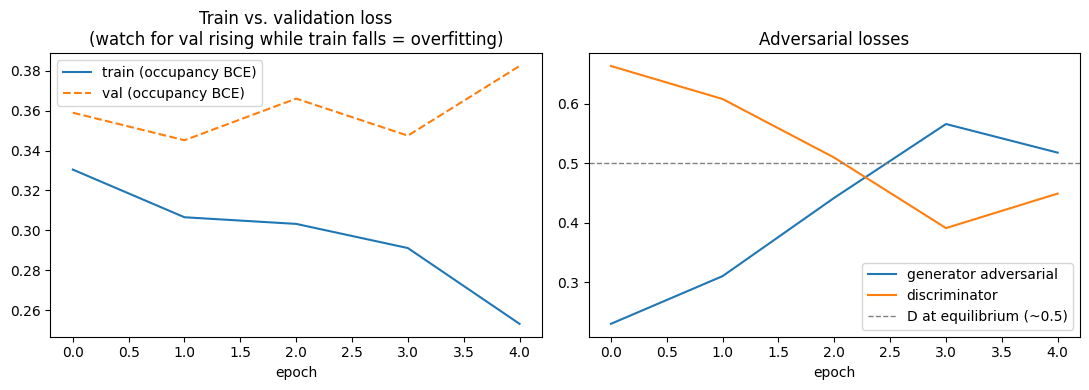

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["loss_rec_occ"], label="train (occupancy BCE)")
axes[0].plot(val_history, label="val (occupancy BCE)", linestyle="--")
axes[0].set_title("Train vs. validation loss\n(watch for val rising while train falls = overfitting)")
axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["loss_g_adv"], label="generator adversarial")
axes[1].plot(history["loss_d"], label="discriminator")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="D at equilibrium (~0.5)")
axes[1].set_title("Adversarial losses"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Evaluate on held-out (video, user) trajectories

Same two-metric approach as the single-trajectory notebook (top-K primary, since it's threshold-free and standard for tile-based FoV work; fixed 0.5-threshold secondary, included for transparency), now measured on entirely unseen video/viewer combinations rather than a later time-slice of the same clip — a stronger generalization test.


In [11]:
def confusion_metrics(pred_bin, target_bin, axis=(0, 2, 3, 4)):
    tp = (pred_bin * target_bin).sum(axis=axis)
    fp = (pred_bin * (1 - target_bin)).sum(axis=axis)
    fn = ((1 - pred_bin) * target_bin).sum(axis=axis)
    tn = ((1 - pred_bin) * (1 - target_bin)).sum(axis=axis)
    prec = tp / (tp + fp + 1e-8); rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8); iou = tp / (tp + fp + fn + 1e-8)
    acc = (tp + tn) / (tp + fp + fn + tn + 1e-8)
    return prec, rec, f1, iou, acc


def topk_metrics(scores, target, K):
    N, H = scores.shape[0], scores.shape[1]
    s_flat = scores.reshape(N, H, -1); t_flat = target.reshape(N, H, -1)
    idx = np.argsort(-s_flat, axis=-1)[..., :K]
    pred_bin = np.zeros_like(s_flat)
    np.put_along_axis(pred_bin, idx, 1.0, axis=-1)
    tp = (pred_bin * t_flat).sum(axis=(0, 2)); fp = (pred_bin * (1 - t_flat)).sum(axis=(0, 2))
    fn = ((1 - pred_bin) * t_flat).sum(axis=(0, 2))
    prec = tp / (tp + fp + 1e-8); rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8); iou = tp / (tp + fp + fn + 1e-8)
    return prec, rec, f1, iou


all_pred, all_base, all_target = [], [], []
for inputs, target, content_target in test_ds:
    pred = model.predict(inputs, deterministic=True)[0]
    last_frame = inputs["tile_short"].numpy()[:, -1:, :, :, :]
    baseline = np.repeat(last_frame, cfg.predict_horizon, axis=1)
    all_pred.append(pred); all_base.append(baseline); all_target.append(target.numpy())

pred = np.concatenate(all_pred, 0); base = np.concatenate(all_base, 0); targ = np.concatenate(all_target, 0)
K = int(round(targ.sum(axis=(2, 3, 4)).mean()))
rng = np.random.default_rng(0)
rand_scores = rng.random(pred.shape)

p_m, r_m, f_m, i_m = topk_metrics(pred, targ, K)
p_b, r_b, f_b, i_b = topk_metrics(base, targ, K)
p_r, r_r, f_r, i_r = topk_metrics(rand_scores, targ, K)

print(f"Top-K evaluation (K={K} tiles) on {meta['n_test_windows']} test windows from UNSEEN trajectories:\n")
print(f"{'horizon':>8s} | {'model F1':>9s} | {'persist. F1':>11s} | {'random F1':>9s} | {'model IoU':>9s} | {'persist. IoU':>12s}")
for h in range(cfg.predict_horizon):
    print(f"{h+1:>8d} | {f_m[h]:>9.3f} | {f_b[h]:>11.3f} | {f_r[h]:>9.3f} | {i_m[h]:>9.3f} | {i_b[h]:>12.3f}")
print(f"\n{'MEAN':>8s} | {f_m.mean():>9.3f} | {f_b.mean():>11.3f} | {f_r.mean():>9.3f} | {i_m.mean():>9.3f} | {i_b.mean():>12.3f}")


Top-K evaluation (K=34 tiles) on 4315 test windows from UNSEEN trajectories:

 horizon |  model F1 | persist. F1 | random F1 | model IoU | persist. IoU
       1 |     0.578 |       0.926 |     0.172 |     0.406 |        0.862
       2 |     0.591 |       0.926 |     0.171 |     0.420 |        0.862
       3 |     0.609 |       0.913 |     0.172 |     0.438 |        0.840
       4 |     0.620 |       0.913 |     0.172 |     0.449 |        0.840
       5 |     0.627 |       0.900 |     0.172 |     0.457 |        0.819
       6 |     0.624 |       0.900 |     0.171 |     0.454 |        0.819
       7 |     0.623 |       0.888 |     0.170 |     0.453 |        0.799
       8 |     0.624 |       0.888 |     0.170 |     0.453 |        0.799
       9 |     0.628 |       0.876 |     0.173 |     0.458 |        0.780
      10 |     0.634 |       0.876 |     0.171 |     0.464 |        0.780
      11 |     0.642 |       0.865 |     0.170 |     0.473 |        0.762
      12 |     0.637 |       0.865

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
horizons = np.arange(1, cfg.predict_horizon + 1)
axes[0].plot(horizons, f_m, "o-", label="Model")
axes[0].plot(horizons, f_b, "s-", label="Persistence baseline")
axes[0].plot(horizons, f_r, "--", color="gray", label="Random")
axes[0].set_xlabel("frames into the future"); axes[0].set_ylabel("Top-K F1"); axes[0].set_title("F1 vs. prediction horizon")
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].plot(horizons, i_m, "o-", label="Model")
axes[1].plot(horizons, i_b, "s-", label="Persistence baseline")
axes[1].plot(horizons, i_r, "--", color="gray", label="Random")
axes[1].set_xlabel("frames into the future"); axes[1].set_ylabel("Top-K IoU"); axes[1].set_title("IoU vs. prediction horizon")
axes[1].legend(); axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
# Secondary: fixed 0.5-threshold metrics (see the single-trajectory notebook's note on
# why these can read near 0 even when the model has learned real structure -- it's a
# calibration/sharpness issue, cross-check against the top-K numbers above).
pred_bin_05 = (pred >= 0.5).astype(np.float32)
p5, r5, f5, i5, a5 = confusion_metrics(pred_bin_05, targ)
print("Fixed 0.5-threshold metrics (mean over horizon):")
print(f"  precision={p5.mean():.3f}  recall={r5.mean():.3f}  F1={f5.mean():.3f}  IoU={i5.mean():.3f}  accuracy={a5.mean():.3f}")
print(f"\nPredicted probability range: [{pred.min():.3f}, {pred.max():.3f}], mean={pred.mean():.3f}")
print(f"True occupancy rate: {targ.mean():.3f}")


## 7. Visualize predictions vs. ground truth (one held-out trajectory)


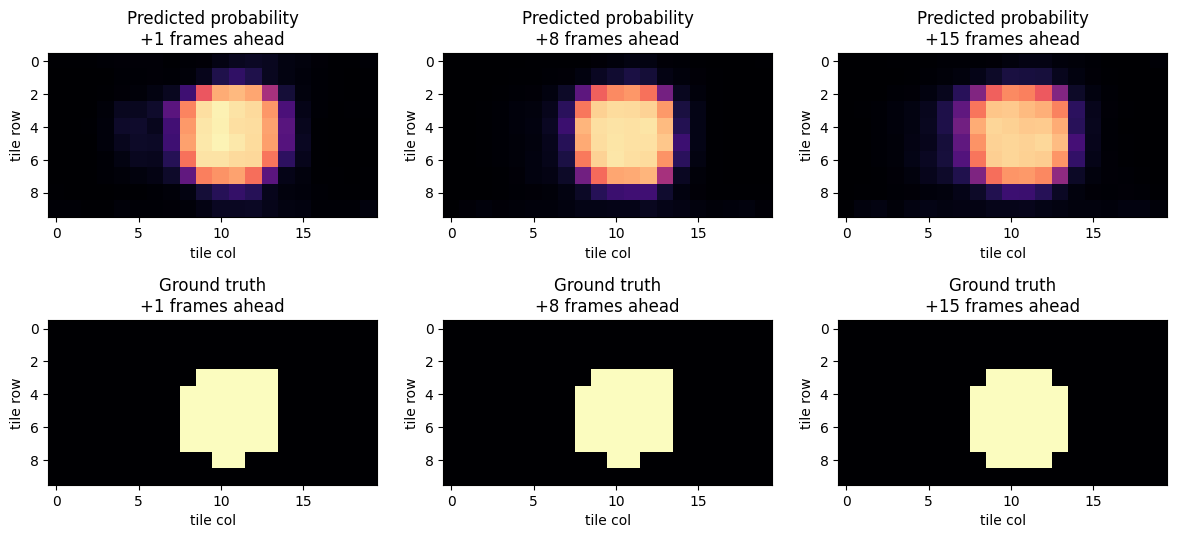

In [12]:
inputs, target, content_target = next(iter(test_ds))
pred_example = model.predict(inputs, deterministic=True)[0]

example_idx = 0
show_frames = [0, cfg.predict_horizon // 2, cfg.predict_horizon - 1]

fig, axes = plt.subplots(2, len(show_frames), figsize=(4 * len(show_frames), 5.5))
for col, h in enumerate(show_frames):
    axes[0, col].imshow(pred_example[example_idx, h, :, :, 0], cmap="magma", vmin=0, vmax=max(0.5, pred_example.max()))
    axes[0, col].set_title(f"Predicted probability\n+{h+1} frames ahead")
    axes[1, col].imshow(target[example_idx, h, :, :, 0].numpy(), cmap="magma", vmin=0, vmax=1)
    axes[1, col].set_title(f"Ground truth\n+{h+1} frames ahead")
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xlabel("tile col"); ax.set_ylabel("tile row")
plt.tight_layout()
plt.show()


## 8. Multiple plausible futures

Sampling the latent `V` multiple times for the same held-out (unseen) input history — the model's core "hedge across plausible outcomes" behavior.


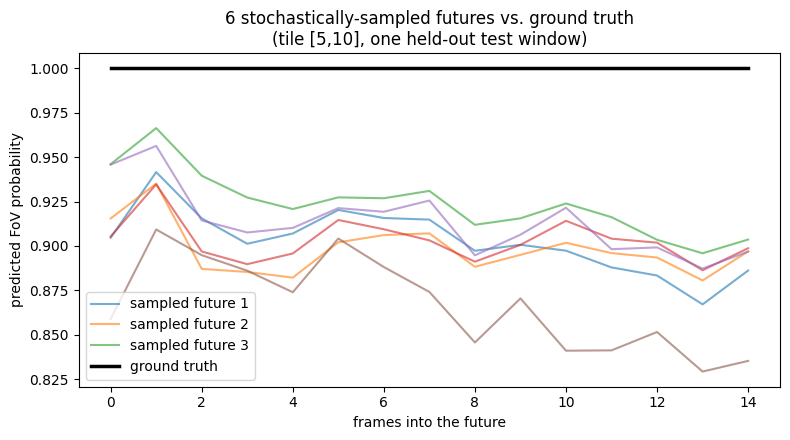

In [13]:
n_samples = 6
stoch_preds = model.predict(inputs, n_samples=n_samples, deterministic=False)

row, col = cfg.grid_h // 2, cfg.grid_w // 2
plt.figure(figsize=(8, 4.5))
for s in range(n_samples):
    plt.plot(stoch_preds[s, example_idx, :, row, col, 0], alpha=0.6, linewidth=1.5,
              label=f"sampled future {s+1}" if s < 3 else None)
plt.plot(target[example_idx, :, row, col, 0].numpy(), color="black", linewidth=2.5, label="ground truth")
plt.title(f"{n_samples} stochastically-sampled futures vs. ground truth\n(tile [{row},{col}], one held-out test window)")
plt.xlabel("frames into the future"); plt.ylabel("predicted FoV probability")
plt.legend(); plt.tight_layout(); plt.show()


## 9. Next steps

- **If discovery found far fewer trajectories than you expected**, check the `[skip]` messages from Section 3 — the most likely cause is a filename that doesn't match the `{video}_{user}_tile.csv` / `{video}_saliency.mp4` pattern exactly, or a truly missing file for some (video, user) pair.
- **Raise `max_videos`/`max_users_per_video`** once you've seen the per-video extraction time — the pipeline caches per-video, so the second and later runs will be much faster regardless.
- **Per-video / per-user breakdown**: right now test metrics are pooled across all held-out trajectories. Splitting the report by "trajectories whose *video* was seen in training (different user)" vs. "trajectories whose *video* was never seen at all" would show more precisely what the model is and isn't generalizing over — worth adding if the pooled numbers look promising and you want to dig deeper.
- **Longer horizons / continuous yaw-pitch-roll head** — same suggestions as the single-trajectory notebook, still apply here.
